# 14 - Extended Error Analysis

Bu notebook **yeni model eğitmez**.

Amaç, mevcut prediction dosyalarındaki yanlış tahminleri sistematik biçimde incelemektir.

Yaptığı işler:
- otomatik hata yönü analizi (`neutral → negative`, `negative → neutral` vb.)
- `neutral → negative` özel özeti
- yüksek güvenle yapılan yanlışların listesi
- manuel nitel analiz için dengeli örnek CSV'si
- manuel kategori rehberi
- hata yönlerini gösteren grafik

Notebook hiçbir nitel hata kategorisini kendi kendine uydurmaz. Manuel kategoriler boş bırakılır.


In [1]:
from thesis_utils import PROJECT_ROOT, paths

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

LABELS = ["negative", "neutral", "positive"]
MANUAL_SAMPLE_PER_MODEL_DATASET = 50
RANDOM_STATE = 42

CHECKPOINT_ROOT = paths.MODEL_CHECKPOINT_ROOT
OUTPUT_DIR = paths.MODEL_RESULTS_ROOT / "extended_error_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint root:", CHECKPOINT_ROOT)
print("Output dir     :", OUTPUT_DIR)


Checkpoint root: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model
Output dir     : D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis


In [2]:
def infer_model(path, df):
    s = str(path).lower()
    if "model" in df.columns and len(df):
        s += " " + str(df["model"].iloc[0]).lower()

    if "distilbert" in s:
        return "DistilBERT"
    if "roberta" in s:
        return "RoBERTa"
    if "finbert" in s:
        if "target_finetuned" in s or "fine-tuned" in s or "fine_tuned" in s:
            return "Fine-tuned FinBERT"
        return "FinBERT"
    if "bert" in s:
        return "BERT"
    return None


def infer_dataset(path, df):
    if "dataset" in df.columns and len(df):
        value = str(df["dataset"].iloc[0]).strip()
        if value:
            return value

    s = str(path).lower().replace("\\", "/")
    if "sp500" in s:
        return "S&P 500"
    if "reuters" in s:
        return "Reuters"
    if "synthetic" in s:
        return "Synthetic"
    if "internal_test" in s or s.endswith("/test_predictions.csv"):
        return "Internal"
    return None


candidate_paths = []
for pattern in ["*predictions*.csv", "*prediction*.csv"]:
    candidate_paths.extend(CHECKPOINT_ROOT.rglob(pattern))

candidate_paths = sorted(set(candidate_paths))
records = []

for path in candidate_paths:
    if "multiseed" in str(path).lower():
        continue

    try:
        df = pd.read_csv(path, encoding="utf-8-sig")
    except Exception:
        try:
            df = pd.read_csv(path)
        except Exception:
            continue

    if len(df) == 0:
        continue

    cols = set(df.columns)
    gold_col = next((c for c in ["gold_label", "label", "true_label"] if c in cols), None)
    pred_col = next((c for c in ["prediction", "predicted_label", "pred_label"] if c in cols), None)

    if gold_col is None or pred_col is None:
        continue

    model = infer_model(path, df)
    dataset = infer_dataset(path, df)

    if model is None or dataset is None:
        continue

    records.append({
        "path": path,
        "model": model,
        "dataset": dataset,
        "gold_col": gold_col,
        "pred_col": pred_col,
        "n_rows": len(df),
    })

discovery_df = pd.DataFrame(records)

if discovery_df.empty:
    raise FileNotFoundError(
        "Prediction CSV bulunamadı. Önce prediction üreten değerlendirme notebooklarını çalıştır."
    )

discovery_df = (
    discovery_df
    .sort_values(["dataset", "model", "path"])
    .drop_duplicates(["dataset", "model"], keep="first")
    .reset_index(drop=True)
)

display(discovery_df.assign(path=discovery_df["path"].astype(str)))


,path,model,dataset,gold_col,pred_col,n_rows
0,D:\serkan.kaymak\financial_sentiment_thesis\fi...,Fine-tuned FinBERT,Internal,gold_label,prediction,2386


In [3]:
TEXT_CANDIDATES = [
    "input_text", "text_en", "text", "headline", "title", "source_text"
]

all_error_frames = []

for row in discovery_df.itertuples(index=False):
    df = pd.read_csv(row.path, encoding="utf-8-sig")

    gold = df[row.gold_col].astype(str).str.lower().str.strip()
    pred = df[row.pred_col].astype(str).str.lower().str.strip()

    valid = gold.isin(LABELS) & pred.isin(LABELS)
    temp = df.loc[valid].copy()
    temp["gold_label_std"] = gold.loc[valid].values
    temp["prediction_std"] = pred.loc[valid].values

    temp = temp[temp["gold_label_std"] != temp["prediction_std"]].copy()
    if len(temp) == 0:
        continue

    text_col = next((c for c in TEXT_CANDIDATES if c in temp.columns), None)
    temp["text_for_review"] = temp[text_col].astype(str) if text_col else ""

    temp["model_std"] = row.model
    temp["dataset_std"] = row.dataset
    temp["error_transition"] = temp["gold_label_std"] + " → " + temp["prediction_std"]

    keep_cols = [
        "model_std", "dataset_std", "gold_label_std",
        "prediction_std", "error_transition", "text_for_review"
    ]

    for optional in [
        "confidence", "prob_negative", "prob_neutral", "prob_positive",
        "annotation_id", "source_dataset"
    ]:
        if optional in temp.columns:
            keep_cols.append(optional)

    all_error_frames.append(temp[keep_cols].copy())

if not all_error_frames:
    raise ValueError("Yanlış tahmin bulunamadı.")

errors_df = pd.concat(all_error_frames, ignore_index=True)

errors_path = OUTPUT_DIR / "all_errors_standardized.csv"
errors_df.to_csv(errors_path, index=False, encoding="utf-8-sig")

print("Toplam hata:", len(errors_df))
display(errors_df.head(10))
print("Saved:", errors_path)


Toplam hata: 282


,model_std,dataset_std,gold_label_std,prediction_std,error_transition,text_for_review,confidence,prob_negative,prob_neutral,prob_positive,source_dataset
0,Fine-tuned FinBERT,Internal,negative,neutral,negative → neutral,Papa John's founder sues ad agency; his wife f...,0.973581,0.026150,0.973581,0.000268,TwitterFinancialNewsSentiment
1,Fine-tuned FinBERT,Internal,positive,neutral,positive → neutral,Volkswagen reveals exotic-sounding ID. Space V...,0.999446,0.000373,0.999446,0.000181,TwitterFinancialNewsSentiment
2,Fine-tuned FinBERT,Internal,negative,neutral,negative → neutral,$BA - 737 MAX crisis claims job of Boeing's to...,0.998566,0.001301,0.998566,0.000133,TwitterFinancialNewsSentiment
3,Fine-tuned FinBERT,Internal,neutral,positive,neutral → positive,"Billboard adding Apple, YouTube plays to Hot 100",0.967193,0.000656,0.032150,0.967193,TwitterFinancialNewsSentiment
4,Fine-tuned FinBERT,Internal,positive,neutral,positive → neutral,Amazon says it signed up new Prime service mem...,0.998399,0.000213,0.998399,0.001388,TwitterFinancialNewsSentiment
5,Fine-tuned FinBERT,Internal,neutral,positive,neutral → positive,Ultra-Short Obligation Funds Wrap Up Their Thi...,0.848552,0.000893,0.150555,0.848552,TwitterFinancialNewsSentiment
6,Fine-tuned FinBERT,Internal,neutral,positive,neutral → positive,Ford to nearly halve its 2018 before interest ...,0.939453,0.059407,0.001140,0.939453,TwitterFinancialNewsSentiment
7,Fine-tuned FinBERT,Internal,neutral,negative,neutral → negative,Richmond Fed Business Survey Shockingly Rises....,0.988238,0.988238,0.004033,0.007729,TwitterFinancialNewsSentiment
8,Fine-tuned FinBERT,Internal,neutral,positive,neutral → positive,Respimat® re-usable inhaler wins 2020 Pharmapa...,0.997392,0.000235,0.002373,0.997392,TwitterFinancialNewsSentiment
9,Fine-tuned FinBERT,Internal,negative,neutral,negative → neutral,La Jolla Pharmaceutical to reassess continued ...,0.998955,0.000837,0.998955,0.000208,TwitterFinancialNewsSentiment


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\all_errors_standardized.csv


In [4]:
transition_counts = (
    errors_df
    .groupby(["dataset_std", "model_std", "error_transition"])
    .size()
    .reset_index(name="error_count")
)

total_errors = (
    errors_df
    .groupby(["dataset_std", "model_std"])
    .size()
    .reset_index(name="total_errors")
)

transition_summary = transition_counts.merge(
    total_errors,
    on=["dataset_std", "model_std"],
    how="left",
)

transition_summary["share_of_model_errors"] = (
    transition_summary["error_count"] / transition_summary["total_errors"]
)

transition_summary = transition_summary.sort_values(
    ["dataset_std", "model_std", "error_count"],
    ascending=[True, True, False],
)

transition_path = OUTPUT_DIR / "error_transition_summary.csv"
transition_summary.to_csv(transition_path, index=False, encoding="utf-8-sig")

display(transition_summary.round(6))
print("Saved:", transition_path)


,dataset_std,model_std,error_transition,error_count,total_errors,share_of_model_errors
3,Internal,Fine-tuned FinBERT,neutral → positive,78,282,0.276596
2,Internal,Fine-tuned FinBERT,neutral → negative,75,282,0.265957
0,Internal,Fine-tuned FinBERT,negative → neutral,52,282,0.184397
5,Internal,Fine-tuned FinBERT,positive → neutral,52,282,0.184397
4,Internal,Fine-tuned FinBERT,positive → negative,17,282,0.060284
1,Internal,Fine-tuned FinBERT,negative → positive,8,282,0.028369


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\error_transition_summary.csv


In [5]:
neutral_negative = errors_df[
    errors_df["error_transition"] == "neutral → negative"
].copy()

nn_counts = (
    neutral_negative
    .groupby(["dataset_std", "model_std"])
    .size()
    .reset_index(name="neutral_to_negative_count")
)

nn_path = OUTPUT_DIR / "neutral_to_negative_error_counts.csv"
nn_counts.to_csv(nn_path, index=False, encoding="utf-8-sig")

print("Neutral → Negative hata sayıları:")
display(nn_counts)
print("Saved:", nn_path)


Neutral → Negative hata sayıları:


,dataset_std,model_std,neutral_to_negative_count
0,Internal,Fine-tuned FinBERT,75


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\neutral_to_negative_error_counts.csv


In [6]:
if "confidence" in errors_df.columns:
    high_conf_errors = (
        errors_df
        .dropna(subset=["confidence"])
        .sort_values("confidence", ascending=False)
        .reset_index(drop=True)
    )

    high_conf_path = OUTPUT_DIR / "high_confidence_errors.csv"
    high_conf_errors.to_csv(high_conf_path, index=False, encoding="utf-8-sig")

    cols = [
        c for c in [
            "dataset_std", "model_std", "error_transition",
            "confidence", "text_for_review"
        ]
        if c in high_conf_errors.columns
    ]

    print("En yüksek confidence'lı ilk 20 hata:")
    display(high_conf_errors[cols].head(20))
    print("Saved:", high_conf_path)
else:
    print("Prediction dosyalarında confidence yok; bu bölüm atlandı.")


En yüksek confidence'lı ilk 20 hata:


,dataset_std,model_std,error_transition,confidence,text_for_review
0,Internal,Fine-tuned FinBERT,negative → neutral,0.999496,"KUDLOW: NO PLANS FOR CHINA, U.S. LEADERS TO ME..."
1,Internal,Fine-tuned FinBERT,positive → neutral,0.999496,"EVI Industries Sets Records for Revenue, Gross..."
2,Internal,Fine-tuned FinBERT,positive → neutral,0.999446,Volkswagen reveals exotic-sounding ID. Space V...
3,Internal,Fine-tuned FinBERT,positive → neutral,0.999443,$IONS $AKCA $AKCA - Akcea and Ionis launches l...
4,Internal,Fine-tuned FinBERT,positive → neutral,0.999412,Saint-Gobain North America Announces Largest R...
5,Internal,Fine-tuned FinBERT,negative → neutral,0.999397,FCC Bigfoots Satellite Companies
6,Internal,Fine-tuned FinBERT,negative → neutral,0.999388,$COUP - Coupa: Don't Buy Into Expensive Valuat...
7,Internal,Fine-tuned FinBERT,negative → neutral,0.999280,$BIL $JPST $VTV - Recession Risk Isn't Off The...
8,Internal,Fine-tuned FinBERT,positive → neutral,0.999279,Amani Gold : Secures Gold Dealers License in T...
9,Internal,Fine-tuned FinBERT,negative → neutral,0.999263,Lagarde Says ECB's Options Limited by Low Rate...


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\high_confidence_errors.csv


In [7]:
rng = np.random.default_rng(RANDOM_STATE)
manual_parts = []

for (dataset, model), group in errors_df.groupby(["dataset_std", "model_std"]):
    n = min(MANUAL_SAMPLE_PER_MODEL_DATASET, len(group))
    transitions = list(group["error_transition"].unique())
    selected_indices = []

    if transitions:
        per_transition = max(1, n // len(transitions))

        for transition in transitions:
            tg = group[group["error_transition"] == transition]
            take = min(per_transition, len(tg))

            if take > 0:
                selected_indices.extend(
                    rng.choice(
                        tg.index.to_numpy(),
                        size=take,
                        replace=False
                    ).tolist()
                )

    selected_indices = list(dict.fromkeys(selected_indices))
    remaining_n = n - len(selected_indices)

    if remaining_n > 0:
        remaining_pool = group.loc[~group.index.isin(selected_indices)]
        take = min(remaining_n, len(remaining_pool))

        if take > 0:
            selected_indices.extend(
                rng.choice(
                    remaining_pool.index.to_numpy(),
                    size=take,
                    replace=False
                ).tolist()
            )

    sampled = group.loc[selected_indices].copy()
    sampled["manual_error_category"] = ""
    sampled["manual_note"] = ""
    manual_parts.append(sampled)

manual_review_df = pd.concat(manual_parts, ignore_index=True)

front_cols = [
    "dataset_std", "model_std", "gold_label_std", "prediction_std",
    "error_transition", "confidence", "text_for_review",
    "manual_error_category", "manual_note"
]

ordered = [c for c in front_cols if c in manual_review_df.columns]
ordered += [c for c in manual_review_df.columns if c not in ordered]
manual_review_df = manual_review_df[ordered]

manual_path = OUTPUT_DIR / "manual_error_review_sample.csv"
manual_review_df.to_csv(manual_path, index=False, encoding="utf-8-sig")

print("Manuel inceleme örnek sayısı:", len(manual_review_df))
display(manual_review_df.head(20))
print("Saved:", manual_path)


Manuel inceleme örnek sayısı: 50


,dataset_std,model_std,gold_label_std,prediction_std,error_transition,confidence,text_for_review,manual_error_category,manual_note,prob_negative,prob_neutral,prob_positive,source_dataset
0,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.993529,Goldman Sachs Says Wealthiest to Back off Stocks,,,0.002383,0.993529,0.004088,TwitterFinancialNewsSentiment
1,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.983469,Hackers have gained access to thousands of Dis...,,,0.016314,0.983469,0.000217,TwitterFinancialNewsSentiment
2,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.992308,"Madhya Pradesh Vyapam Scam: Man Gets 10 Years,...",,,0.007486,0.992308,0.000206,TwitterFinancialNewsSentiment
3,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.986329,Why Aurora Cannabis Is Getting Hammered Today,,,0.003292,0.986329,0.010378,TwitterFinancialNewsSentiment
4,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.990426,Schweizerische Nationalbank : Switzerland Lose...,,,0.009375,0.990426,0.000199,TwitterFinancialNewsSentiment
5,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.992704,Oil prices fall but hold near three-month high...,,,0.003055,0.992704,0.004241,TwitterFinancialNewsSentiment
6,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.625272,Needham's Martin Defends Her Prediction That N...,,,0.368803,0.625272,0.005925,TwitterFinancialNewsSentiment
7,Internal,Fine-tuned FinBERT,negative,neutral,negative → neutral,0.998057,"Forget 'Ides Of March', Washington 'Storms Of ...",,,0.001784,0.998057,0.000159,TwitterFinancialNewsSentiment
8,Internal,Fine-tuned FinBERT,positive,neutral,positive → neutral,0.998242,Kodak Is Having a Comeback Moment as Oscars Em...,,,0.000400,0.998242,0.001358,TwitterFinancialNewsSentiment
9,Internal,Fine-tuned FinBERT,positive,neutral,positive → neutral,0.999412,Saint-Gobain North America Announces Largest R...,,,0.000288,0.999412,0.000300,TwitterFinancialNewsSentiment


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\manual_error_review_sample.csv


In [8]:
category_template = pd.DataFrame({
    "manual_error_category": [
        "mixed_information",
        "expectation_comparison",
        "ambiguous_market_direction",
        "entity_target_ambiguity",
        "negation_or_contrast",
        "numeric_financial_context",
        "annotation_semantics_mismatch",
        "other",
    ],
    "short_description": [
        "Aynı metinde olumlu ve olumsuz sinyaller birlikte bulunuyor.",
        "Sonuç, beklenti/tahmin/önceki dönem ile kıyaslanmadan yorumlanamıyor.",
        "Metin net bir piyasa yönü taşımıyor veya etki belirsiz.",
        "Duygunun hangi şirket/varlık/hedef için olduğu belirsiz.",
        "Olumsuzlama veya karşıtlık yapıları etkili.",
        "Yüzeysel kelimeden çok sayısal finansal bağlam belirleyici.",
        "Model mantığı ile veri setinin etiket semantiği uyuşmuyor.",
        "Diğer.",
    ]
})

category_template_path = OUTPUT_DIR / "manual_error_category_guide.csv"
category_template.to_csv(category_template_path, index=False, encoding="utf-8-sig")

display(category_template)
print("Saved:", category_template_path)


,manual_error_category,short_description
0,mixed_information,Aynı metinde olumlu ve olumsuz sinyaller birli...
1,expectation_comparison,"Sonuç, beklenti/tahmin/önceki dönem ile kıyasl..."
2,ambiguous_market_direction,Metin net bir piyasa yönü taşımıyor veya etki ...
3,entity_target_ambiguity,Duygunun hangi şirket/varlık/hedef için olduğu...
4,negation_or_contrast,Olumsuzlama veya karşıtlık yapıları etkili.
5,numeric_financial_context,Yüzeysel kelimeden çok sayısal finansal bağlam...
6,annotation_semantics_mismatch,Model mantığı ile veri setinin etiket semantiğ...
7,other,Diğer.


Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\manual_error_category_guide.csv


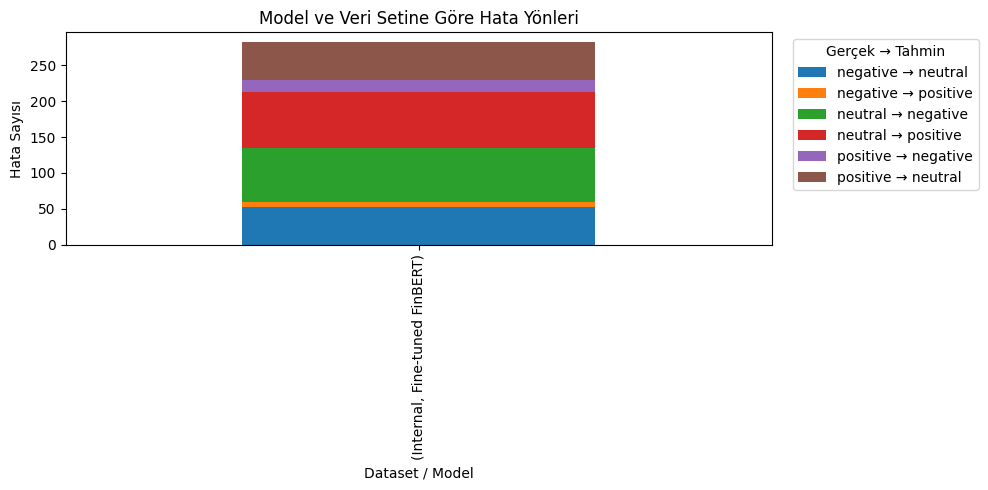

Saved: D:\serkan.kaymak\financial_sentiment_thesis\financial_sentiment_thesis\checkpoints\financial_sentiment_multi_model\extended_error_analysis\error_transition_stacked_bar.png


In [9]:
plot_df = (
    transition_summary
    .pivot_table(
        index=["dataset_std", "model_std"],
        columns="error_transition",
        values="error_count",
        fill_value=0,
    )
)

if len(plot_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title("Model ve Veri Setine Göre Hata Yönleri")
    ax.set_xlabel("Dataset / Model")
    ax.set_ylabel("Hata Sayısı")
    ax.legend(
        title="Gerçek → Tahmin",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    fig.tight_layout()

    plot_path = OUTPUT_DIR / "error_transition_stacked_bar.png"
    fig.savefig(plot_path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", plot_path)


In [10]:
def summarize_manual_categories(csv_path=manual_path):
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if "manual_error_category" not in df.columns:
        raise ValueError("manual_error_category kolonu yok.")

    df["manual_error_category"] = (
        df["manual_error_category"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    labeled = df[df["manual_error_category"] != ""].copy()

    if len(labeled) == 0:
        print(
            "Henüz manuel kategori girilmemiş. "
            "manual_error_review_sample.csv dosyasını doldurduktan sonra bu hücreyi tekrar çalıştır."
        )
        return pd.DataFrame()

    summary = (
        labeled
        .groupby(["dataset_std", "model_std", "manual_error_category"])
        .size()
        .reset_index(name="count")
    )

    totals = (
        labeled
        .groupby(["dataset_std", "model_std"])
        .size()
        .reset_index(name="labeled_errors")
    )

    summary = summary.merge(
        totals,
        on=["dataset_std", "model_std"],
        how="left"
    )

    summary["share"] = summary["count"] / summary["labeled_errors"]

    out_path = OUTPUT_DIR / "manual_error_category_summary.csv"
    summary.to_csv(out_path, index=False, encoding="utf-8-sig")

    display(
        summary.sort_values(
            ["dataset_std", "model_std", "count"],
            ascending=[True, True, False]
        ).round(6)
    )

    print("Saved:", out_path)
    return summary


manual_category_summary = summarize_manual_categories()


Henüz manuel kategori girilmemiş. manual_error_review_sample.csv dosyasını doldurduktan sonra bu hücreyi tekrar çalıştır.


## Bana göndermen gerekenler

İlk çalıştırmadan sonra:

- `extended_error_analysis/error_transition_summary.csv`
- `extended_error_analysis/neutral_to_negative_error_counts.csv`
- `extended_error_analysis/manual_error_review_sample.csv`

dosyalarını sakla.

`manual_error_review_sample.csv` içindeki `manual_error_category` sütununu doldurduktan sonra
son hücreyi tekrar çalıştırırsan `manual_error_category_summary.csv` oluşur.

Varsayılan olarak her `model × dataset` çifti için en fazla **50 yanlış örnek** seçilir.
